In [1]:
import os
os.environ['PROJ_LIB'] = '/data/home/globc/bonassies/.conda/envs/conda3.10/share/proj'
# import earthaccess
from pathlib import Path
import pyproj
from shapely.geometry import shape, box
import shapely
import numpy as np
import xarray as xr
import geopandas as gpd
import pandas as pd

import matplotlib
import matplotlib.colors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

import rioxarray as xrio
import rasterio as rio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show


import datetime

from IPython.display import Image
import glob

from sklearn.mixture import GaussianMixture
from pylab import concatenate, normal
from scipy.stats import norm

from osgeo import gdal
import rioxarray as rxr


from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
from skimage.filters import threshold_otsu
from skimage.filters.rank import majority
from skimage import morphology

os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')

import configparser
from pathlib import Path
from core.swot_project import SwotProject
from auxiliary.cbar_ESA_WC import *
from auxiliary.cbar_SWOT import *
from auxiliary.plot_variables import *
from auxiliary.tools import *

from eomaps import Maps


cmap_ESAWC, normalizer_ESAWC, boundaries_ESAWC, ticks_ESAWC, tick_labels_ESAWC, values_ESAWC = defined_ESAWC_cmap()
cmap_SWOT, normalizer_SWOT, boundaries_SWOT, ticks_SWOT, tick_labels_SWOT, values_SWOT = defined_SWOT_cmap()

In [2]:
data_path = "/data/scratch/globc/bonassies/data"
workspace_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples"
project =  'Paper_SWOT'
PortoAlegre = "PortoAlegre"
Chinon = "Chinon"
EMSR692 = "EMSR_692"
Ohio = "Ohio"   

PROJECT_PATH = os.path.join(workspace_path, project)
FIGS_FOLDER = os.path.join(PROJECT_PATH, 'Figs')

Chinon_PATH = os.path.join(workspace_path, Chinon)
Chinon_raster_PATH = os.path.join(Chinon_PATH, 'rasters')
Chinon_aux_PATH = os.path.join(Chinon_PATH, 'aux_data')

PortoAlegre_PATH = os.path.join(workspace_path, PortoAlegre)
PortoAlegre_raster_PATH = os.path.join(PortoAlegre_PATH, 'rasters')
PortoAlegre_aux_PATH = os.path.join(PortoAlegre_PATH, 'aux_data')

EMSR692_PATH = os.path.join(workspace_path, EMSR692)
EMSR692_raster_PATH = os.path.join(EMSR692_PATH, 'rasters')
EMSR692_aux_PATH = os.path.join(EMSR692_PATH, 'aux_data')

Ohio_PATH = os.path.join(workspace_path, Ohio)
Ohio_raster_PATH = os.path.join(Ohio_PATH, 'rasters')
Ohio_aux_PATH = os.path.join(Ohio_PATH, 'aux_data')

In [4]:
####
file = os.path.join(PortoAlegre_aux_PATH, 'aoi.gpkg')
bbox_PortoAlegre = gpd.read_file(file)
aoi2_PortoAleger = box(bbox_PortoAlegre.bounds["minx"][0], bbox_PortoAlegre.bounds["miny"][0], bbox_PortoAlegre.bounds['maxx'][0], bbox_PortoAlegre.bounds["maxy"][0])

####
file = os.path.join(Chinon_aux_PATH, 'aoi.gpkg')
bbox_Chinon = gpd.read_file(file)
print(bbox_Chinon)
aoi2_Chinon = box(bbox_Chinon.bounds["minx"][0], bbox_Chinon.bounds["miny"][0], bbox_Chinon.bounds['maxx'][0], bbox_Chinon.bounds["maxy"][0])

####
file = os.path.join(EMSR692_aux_PATH, 'EMSR692_aois_V2.gpkg')
bbox_EMSR692 = gpd.read_file(file)
aoi2_EMSR692 = box(bbox_EMSR692.bounds["minx"][0], bbox_EMSR692.bounds["miny"][0], bbox_EMSR692.bounds['maxx'][0], bbox_EMSR692.bounds["maxy"][0])

###
file = os.path.join(Ohio_aux_PATH, 'aoi_4326.gpkg')
bbox_Ohio = gpd.read_file(file)
aoi2_Ohio = box(bbox_Ohio.bounds["minx"][0], bbox_Ohio.bounds["miny"][0], bbox_Ohio.bounds['maxx'][0], bbox_Ohio.bounds["maxy"][0])

SWOT_SWATH = "swot_science_hr_Aug2021-v05_shapefile_swath_studied.gpkg"
file = os.path.join(PROJECT_PATH, SWOT_SWATH)
swath = gpd.read_file(file)


                                            geometry
0  POLYGON ((0.06 47.225, 0.06 47.1, 0.4 47.1, 0....


In [5]:

cond = np.logical_or(
    np.logical_or(
        np.logical_or(swath.ID_PASS == 113, swath.ID_PASS == 533), 
        swath.ID_PASS == 481),
    swath.ID_PASS == 402
    )
swath.where(cond)
# swath

,ID_SEG,ID_PASS,START_TIME,geometry
0,566.0,113.0,Day 05 00:38:32,"MULTIPOLYGON (((-3.11304 36.73544, -3.66105 36..."
1,NaN,NaN,NaN,None
2,NaN,NaN,NaN,None
3,1981.0,402.0,Day 15 07:59:53,"MULTIPOLYGON (((15.66897 54.2369, 16.3966 54.3..."
4,NaN,NaN,NaN,None
5,2362.0,481.0,Day 18 04:08:27,"MULTIPOLYGON (((-88.96872 28.18316, -89.47002 ..."
6,NaN,NaN,NaN,None
7,2600.0,533.0,Day 20 00:26:00,"MULTIPOLYGON (((-52.37025 -32.35032, -52.89074..."


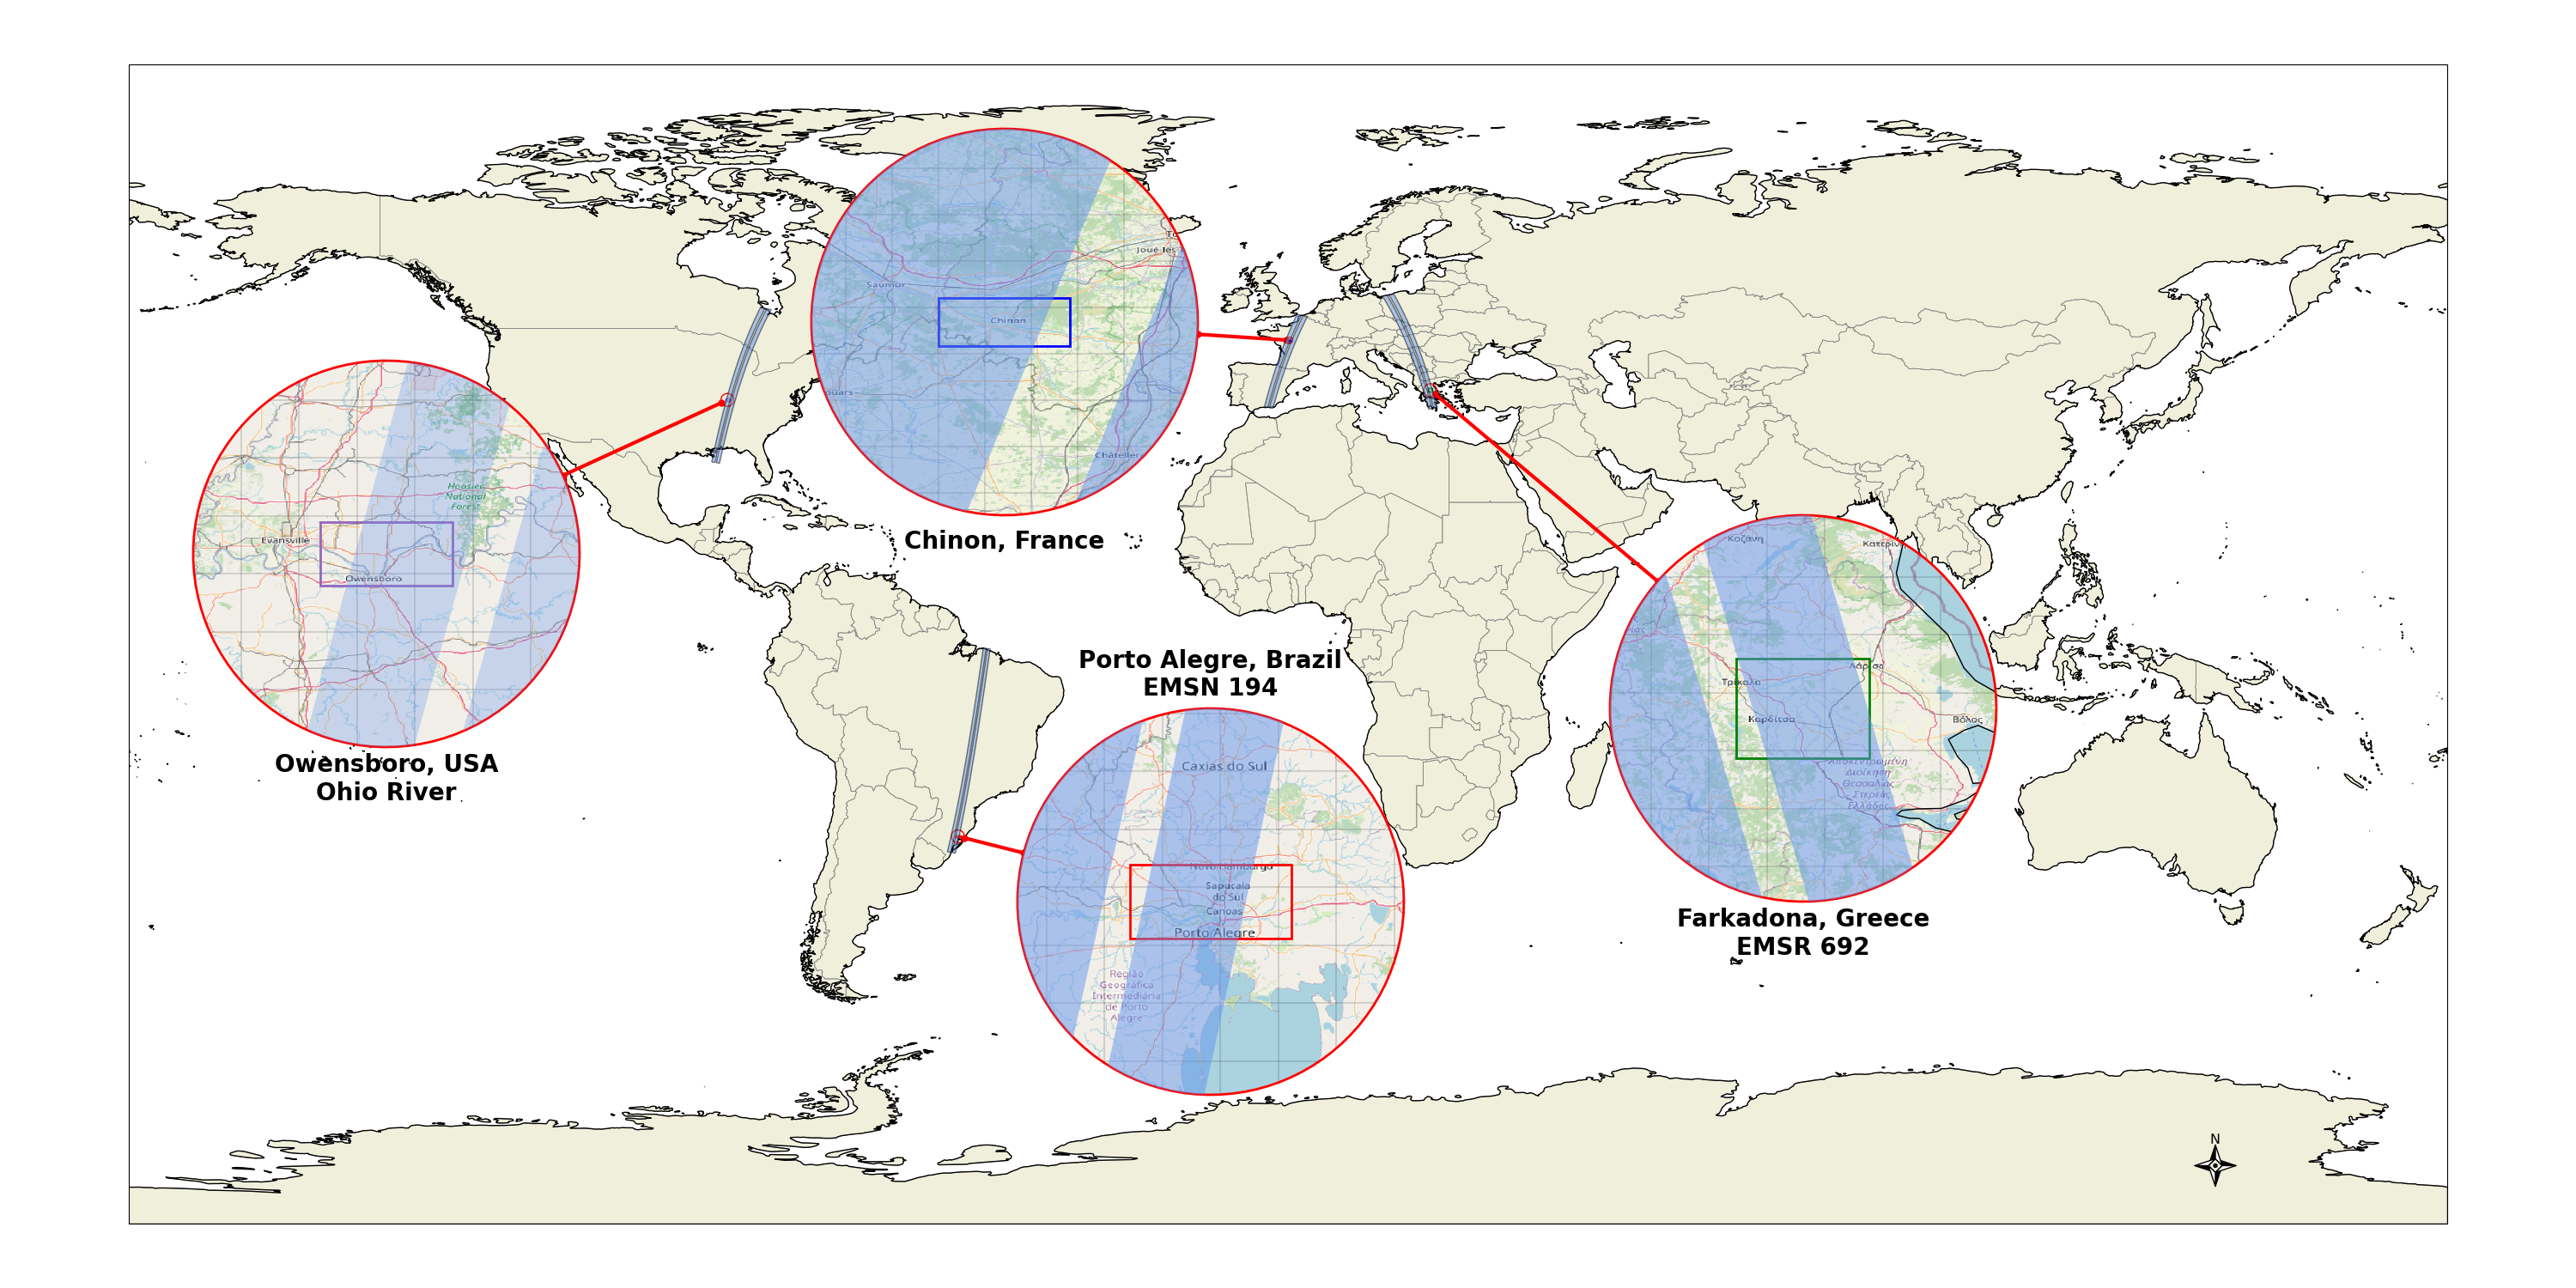

In [6]:
m = Maps(crs='EPSG:4326', figsize=(30,15))
m.set_extent([-180, 180, -90, 90])
c = m.add_compass(style='compass', pos=(0.9, 0.05), scale=8)

m.add_feature.preset("coastline", "countries", "land")

m_aoi_ax = m.ax
m_aoi_ax.add_patch(Polygon([[aoi2_PortoAleger.bounds[0], aoi2_PortoAleger.bounds[1]],
                             [aoi2_PortoAleger.bounds[0], aoi2_PortoAleger.bounds[3]],
                             [aoi2_PortoAleger.bounds[2], aoi2_PortoAleger.bounds[3]],
                             [aoi2_PortoAleger.bounds[2], aoi2_PortoAleger.bounds[1]]],
                            edgecolor='red', facecolor='none', lw=1))
m_aoi_ax.add_patch(Polygon([[aoi2_Chinon.bounds[0], aoi2_Chinon.bounds[1]],
                                [aoi2_Chinon.bounds[0], aoi2_Chinon.bounds[3]],
                                [aoi2_Chinon.bounds[2], aoi2_Chinon.bounds[3]],
                                [aoi2_Chinon.bounds[2], aoi2_Chinon.bounds[1]]],
                            edgecolor='blue', facecolor='none', lw=1))
m_aoi_ax.add_patch(Polygon([[aoi2_EMSR692.bounds[0], aoi2_EMSR692.bounds[1]],
                                [aoi2_EMSR692.bounds[0], aoi2_EMSR692.bounds[3]],
                                [aoi2_EMSR692.bounds[2], aoi2_EMSR692.bounds[3]],
                                [aoi2_EMSR692.bounds[2], aoi2_EMSR692.bounds[1]]],
                            edgecolor='green', facecolor='none', lw=1))


bbox_Ohio = bbox_Ohio.to_crs('EPSG:4326')
aoi2_Ohio = box(bbox_Ohio.bounds["minx"][0], bbox_Ohio.bounds["miny"][0], bbox_Ohio.bounds["maxx"][0], bbox_Ohio.bounds["maxy"][0])
m_aoi_ax.add_patch(Polygon([[aoi2_Ohio.bounds[0], aoi2_Ohio.bounds[1]],
                                [aoi2_Ohio.bounds[0], aoi2_Ohio.bounds[3]],
                                [aoi2_Ohio.bounds[2], aoi2_Ohio.bounds[3]],
                                [aoi2_Ohio.bounds[2], aoi2_Ohio.bounds[1]]],
                            edgecolor='tab:purple', facecolor='none', lw=1))
m.add_gdf(swath.where(cond), permanent = False, fc="cornflowerblue", ec='black', lw=1, alpha=0.5)


m_zoom1 = m.new_inset_map(xy=aoi2_PortoAleger.centroid.coords[0], radius=1, plot_position=(0.47, 0.3), plot_size=0.3, indicator_line=dict(lw=3, marker="o", ms=5))
m_zoom1.add_title('Porto Alegre, Brazil\nEMSN 194', fontsize=20, fontweight='bold', y=1.02)
m_zoom1.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
m_zoom1.add_wms.OpenStreetMap.add_layer.default()
m_zoom1.ax.add_patch(Polygon([[aoi2_PortoAleger.bounds[0], aoi2_PortoAleger.bounds[1]],
                             [aoi2_PortoAleger.bounds[0], aoi2_PortoAleger.bounds[3]],
                             [aoi2_PortoAleger.bounds[2], aoi2_PortoAleger.bounds[3]],
                             [aoi2_PortoAleger.bounds[2], aoi2_PortoAleger.bounds[1]]],
                            edgecolor='red', facecolor='none', lw=2))
m_zoom1.add_gdf(swath.where(cond), permanent = False, fc="cornflowerblue", ec='none', lw=1, alpha=0.5)

m_zoom2 = m.new_inset_map(xy=aoi2_Chinon.centroid.coords[0], radius=0.5, plot_position=(0.39, 0.75), plot_size=0.3, indicator_line=dict(lw=3, marker="o", ms=5))
m_zoom2.add_title('Chinon, France', fontsize=20, fontweight='bold', y=-0.1)
m_zoom2.add_wms.OpenStreetMap.add_layer.default()
m_zoom2.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
m_zoom2.ax.add_patch(Polygon([[aoi2_Chinon.bounds[0], aoi2_Chinon.bounds[1]],
                                [aoi2_Chinon.bounds[0], aoi2_Chinon.bounds[3]],
                                [aoi2_Chinon.bounds[2], aoi2_Chinon.bounds[3]],
                                [aoi2_Chinon.bounds[2], aoi2_Chinon.bounds[1]]],
                            edgecolor='blue', facecolor='none', lw=2))
m_zoom2.add_gdf(swath.where(cond), permanent = False, fc="cornflowerblue", ec='none', lw=1, alpha=0.5)

m_zoom3 = m.new_inset_map(xy=aoi2_EMSR692.centroid.coords[0], radius=1, plot_position=(0.7, 0.45), plot_size=0.3,indicator_line=dict(lw=3, marker="o", ms=5))
m_zoom3.add_title('Farkadona, Greece\nEMSR 692', fontsize=20, fontweight='bold', y=-0.15)
m_zoom3.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
m_zoom3.add_feature.preset("coastline", "countries", "rivers_lake_centerlines")
m_zoom3.add_wms.OpenStreetMap.add_layer.default()
m_zoom3.ax.add_patch(Polygon([[aoi2_EMSR692.bounds[0], aoi2_EMSR692.bounds[1]],
                                [aoi2_EMSR692.bounds[0], aoi2_EMSR692.bounds[3]],
                                [aoi2_EMSR692.bounds[2], aoi2_EMSR692.bounds[3]],
                                [aoi2_EMSR692.bounds[2], aoi2_EMSR692.bounds[1]]],
                            edgecolor='green', facecolor='none', lw=2))
m_zoom3.add_gdf(swath.where(cond), permanent = False, fc="cornflowerblue", ec='none', lw=1, alpha=0.5)

m_zoom4 = m.new_inset_map(xy=aoi2_Ohio.centroid.coords[0], radius=1, plot_position=(0.15, 0.57), plot_size=0.3, indicator_line=dict(lw=3, marker="o", ms=5))
m_zoom4.add_title('Owensboro, USA\nOhio River', fontsize=20, fontweight='bold', y=-.15)
m_zoom4.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
m_zoom4.add_wms.OpenStreetMap.add_layer.default()
m_zoom4.ax.add_patch(Polygon([[aoi2_Ohio.bounds[0], aoi2_Ohio.bounds[1]],
                                [aoi2_Ohio.bounds[0], aoi2_Ohio.bounds[3]],
                                [aoi2_Ohio.bounds[2], aoi2_Ohio.bounds[3]],
                                [aoi2_Ohio.bounds[2], aoi2_Ohio.bounds[1]]],
                            edgecolor='tab:purple', facecolor='none', lw=2))
m_zoom4.add_gdf(swath.where(cond), permanent = False, fc="cornflowerblue", ec='none', lw=1, alpha=0.3)

# m.show()
m.savefig(os.path.join(FIGS_FOLDER, "AOIs.png"), dpi=300)